# Section 00 - Getting Ready

In [108]:
import pandas as pd
import numpy as np
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.decomposition import PCA

------
# Section 01 - Linear regression for Predicting Heights

To start, read the provided heights dataset using the following line of code (it’s your own heights data):

In [109]:
heights = pd.read_csv('../Datasets/height.csv',usecols=['height', 'sex', 'mother', 'father']).dropna()

heights['sex'] = heights['sex'].str.upper()
heights.loc[heights['sex'] == 'W', 'sex'] = 'F'

heights.head()

,height,sex,mother,father
0,150,F,170.0,177.0
1,152,F,157.0,175.0
2,152,F,155.0,156.0
3,153,F,155.0,175.0
4,153,F,150.0,176.0


1. Let’s focus on one sex. Fit a linear model for each male’s height given the father’s height. Then, fit
another linear model for the father’s height given each male’s height.

In [110]:
heights_male = heights[heights['sex'] == 'M'].copy()

m1 = smf.ols('height ~ father', data = heights_male).fit()
print(m1.summary2().tables[1])

m2 = smf.ols('father ~ height', data = heights_male).fit()
print(m2.summary2().tables[1])

               Coef.  Std.Err.          t         P>|t|     [0.025      0.975]
Intercept  93.983299  8.403878  11.183325  2.507584e-24  77.442003  110.524596
father      0.488549  0.047318  10.324824  1.895175e-21   0.395413    0.581684
               Coef.  Std.Err.          t         P>|t|     [0.025     0.975]
Intercept  77.024150  9.733204   7.913545  5.530516e-14  57.866351  96.181949
height      0.555783  0.053830  10.324824  1.895175e-21   0.449830   0.661736


2. Predict each male student’s height given the father’s height (predict()) and predict each father’s
height given each male student’s height. Store both predictions into new columns of a data table. Then,
plot the original data and additionally both regression lines. Hint: use geom_line.

In [111]:
heights_male['predicted_students_height'] = m1.predict(heights_male['father'])
heights_male['predicted_fathers_height']  = m2.predict(heights_male['height'])

heights_male.head()

,height,sex,mother,father,predicted_students_height,predicted_fathers_height
10,155,M,170.0,173.0,178.502205,163.170479
69,163,M,150.0,168.0,176.059462,167.616741
82,163,M,155.0,162.0,173.128170,167.616741
111,164,M,161.0,193.0,188.273176,168.172524
124,165,M,157.0,178.0,180.944947,168.728307


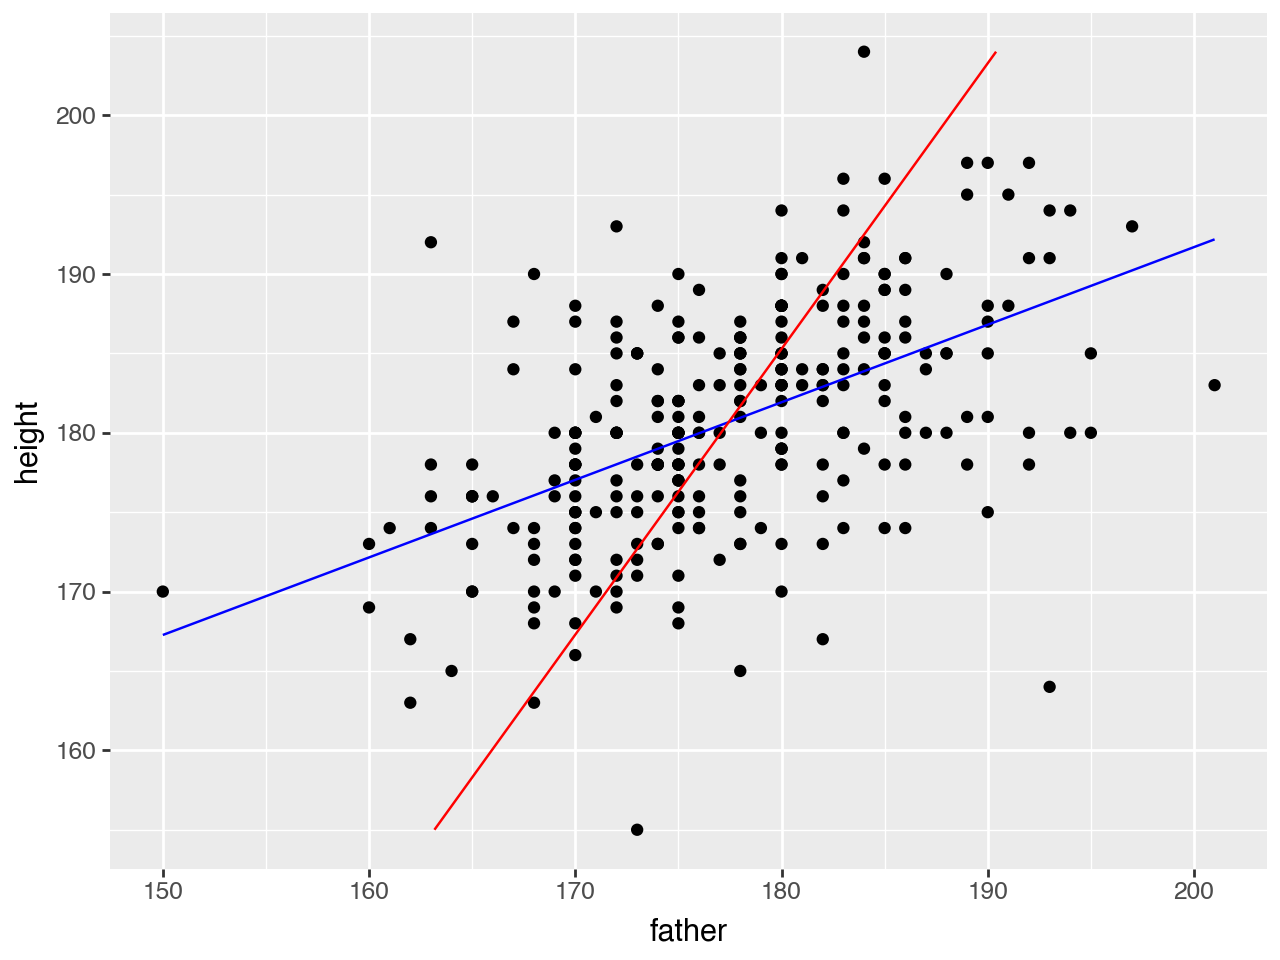

In [112]:
(
    ggplot(heights_male, aes('father', 'height')) + 
    geom_point() +
    geom_line(aes('father', 'predicted_students_height'), color = 'blue') +
    geom_line(aes('predicted_fathers_height', 'height'), color = 'red')
)

3. Additionally, run a PCA on the same subset of the data and plot the first principal component line
into the same figure. 

Hint: you can get the unit vector of the first principal component by accessing
the components_ attribute of the object obtained from PCA. Given this unit vector compute the slope
and intercept and use geom_abline to plot the resulting line. Remember that the slope, 𝑚, of a line
can be calculated from the coordinates (𝑢𝑥
, 𝑢𝑦
) of its unit vector, 𝑚 =
𝑢𝑦
𝑢𝑥
and recall that the principal
component line contains the center of the data. Use geom_abline to plot the line from the computed
intercept and slope

In [113]:
import sklearn

X = heights_male[['height', 'father']]

X = sklearn.preprocessing.StandardScaler().fit_transform(X)

pca_res = sklearn.decomposition.PCA().fit(X)

pca_res.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

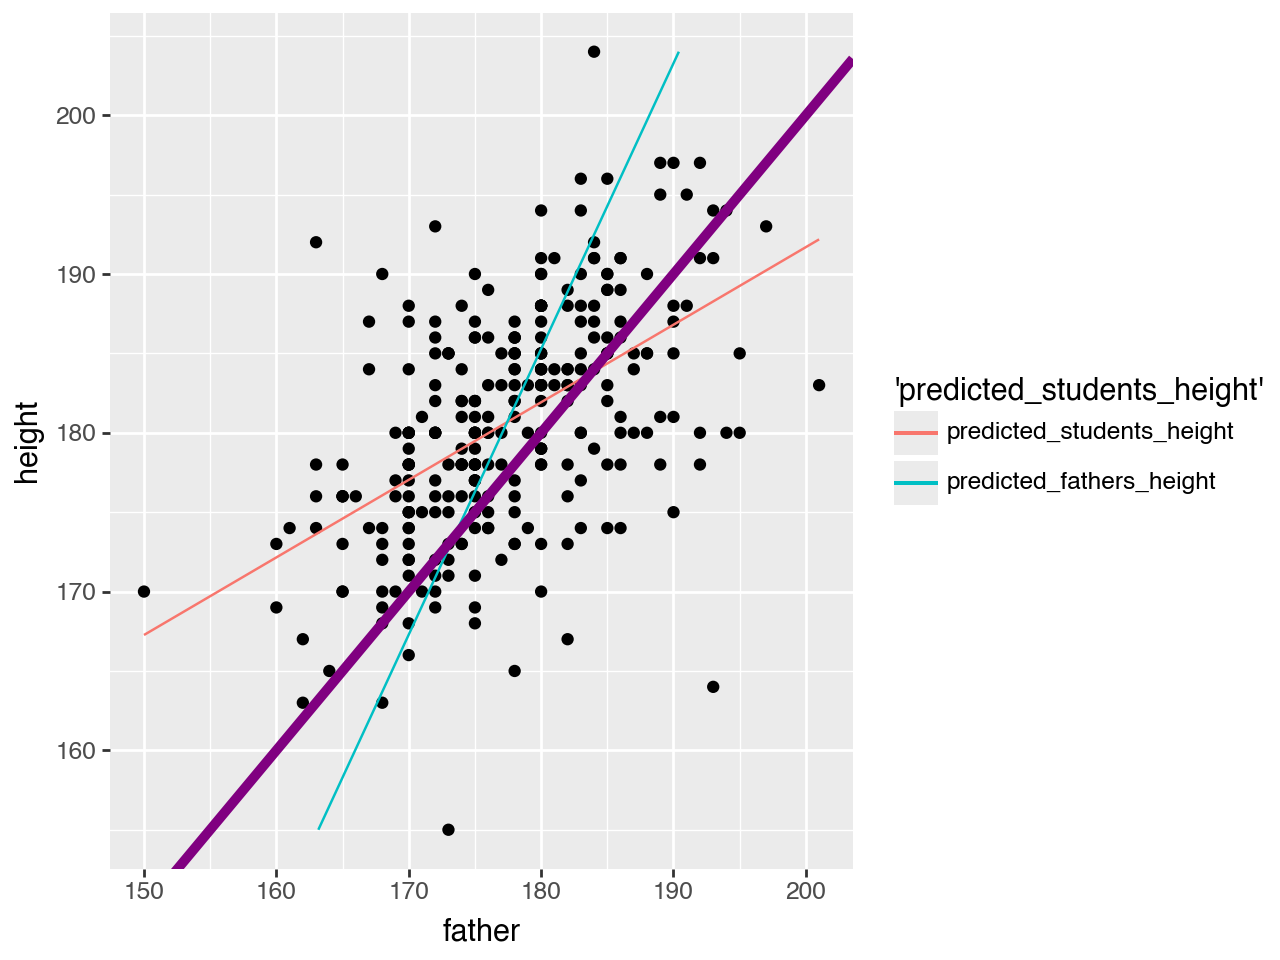

In [114]:
comp1 = pca_res.components_[0]
slope1 = comp1[1] / comp1[0]

mean_father = pca_res.mean_[0]
mean_student = pca_res.mean_[1]

intercept = mean_student - mean_father * slope1

(
    ggplot(heights_male) + 
    geom_point(aes('father', 'height')) +
    geom_line(aes('father', 'predicted_students_height' , color = "'predicted_students_height'")) +
    geom_line(aes('predicted_fathers_height', 'height', color = "'predicted_fathers_height'")) +
    geom_abline(intercept = intercept, slope = slope1, color = 'purple', size = 2)
)

4. Interpret the plot from above. How can we explain the different slopes of the two linear models and
the pca?

Linear models minimize the RSS along the predicted coordinate. In this specific case, such coordinate is
either the male student’s height (first model of the students heights) or the fathers height (second model
predicting the fathers heights). PCA minimizes the sum of squares (along both coordinates). And hence,
the distance perpendicular to the first principal component. PC1 is the line with respect to which the
sum of PC1 represents the line such that the sum of the squared distances of every point (x,y) to it is the
minimum across all possible lines.

5. For the model predicting each male height given the father’s height, check the plot of the residual
vs the predicted values and the Q-Q plot of the residuals. Do these plots provide evidence against the
assumptions of linear regression?

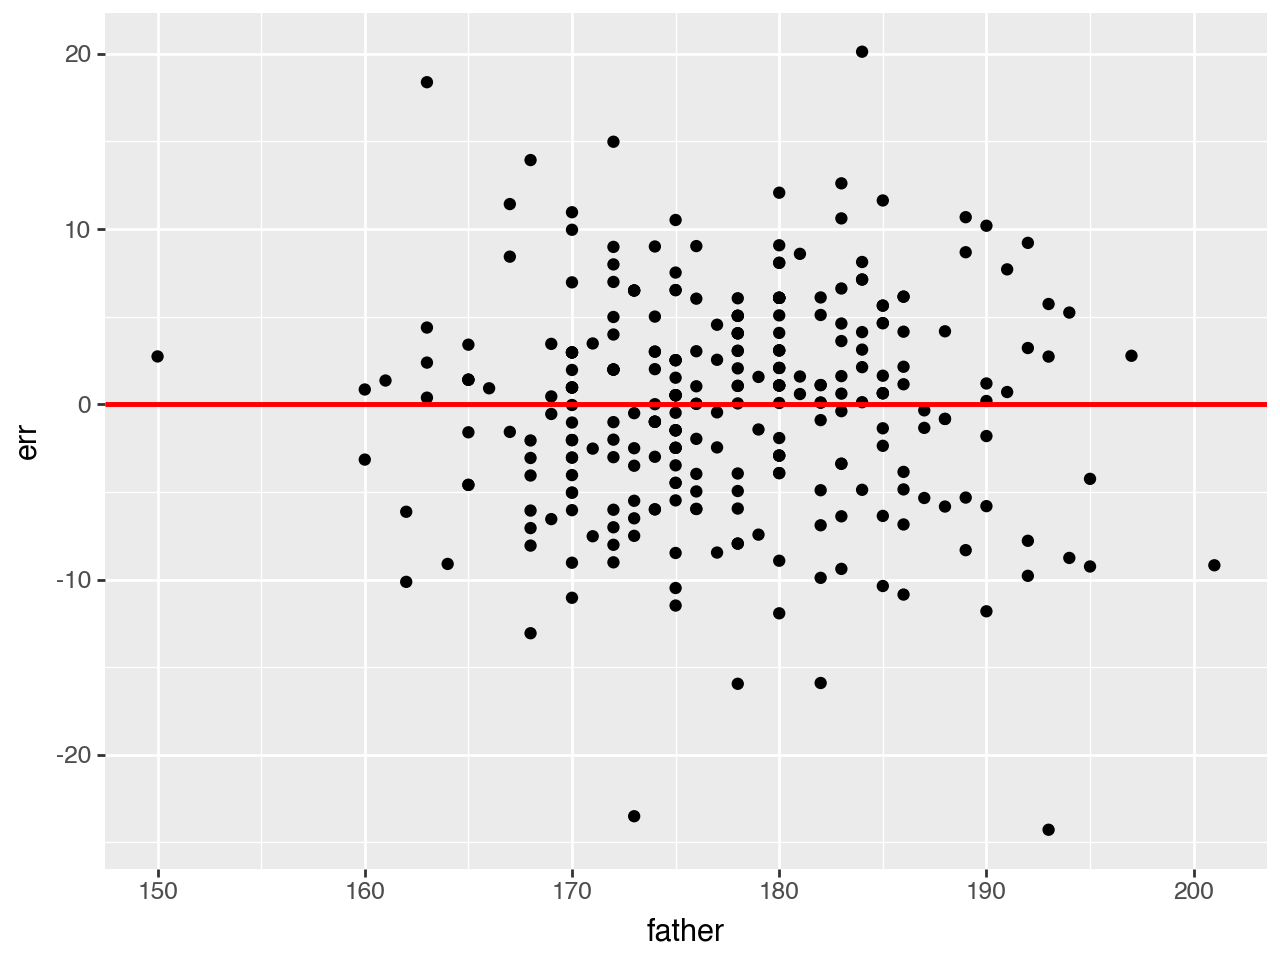

In [115]:
heights_male['err'] = heights_male['height'] - heights_male['predicted_students_height']
heights_male.head()

(
    ggplot(heights_male, aes('father', 'err')) + 
    geom_point() +
    geom_hline(yintercept = 0, color = 'red', size = 1)
)

The assumptions of linear regressions are: The expected values of the response are a linear combinations
of the explanatory variables Errors are identically and independently distributed. Errors follow a normal
distribution with constant variance across all explanatory variable values

The average of the residuals doesn’t seem to change across predicted values. Therefore the residual vs
predicted values plot doesn’t provide evidence against the linearity assumption

The variance of the residuals seems to be constant across predicted values. Together with the previous
observation, this supports that the errors are identically and independently distributed.

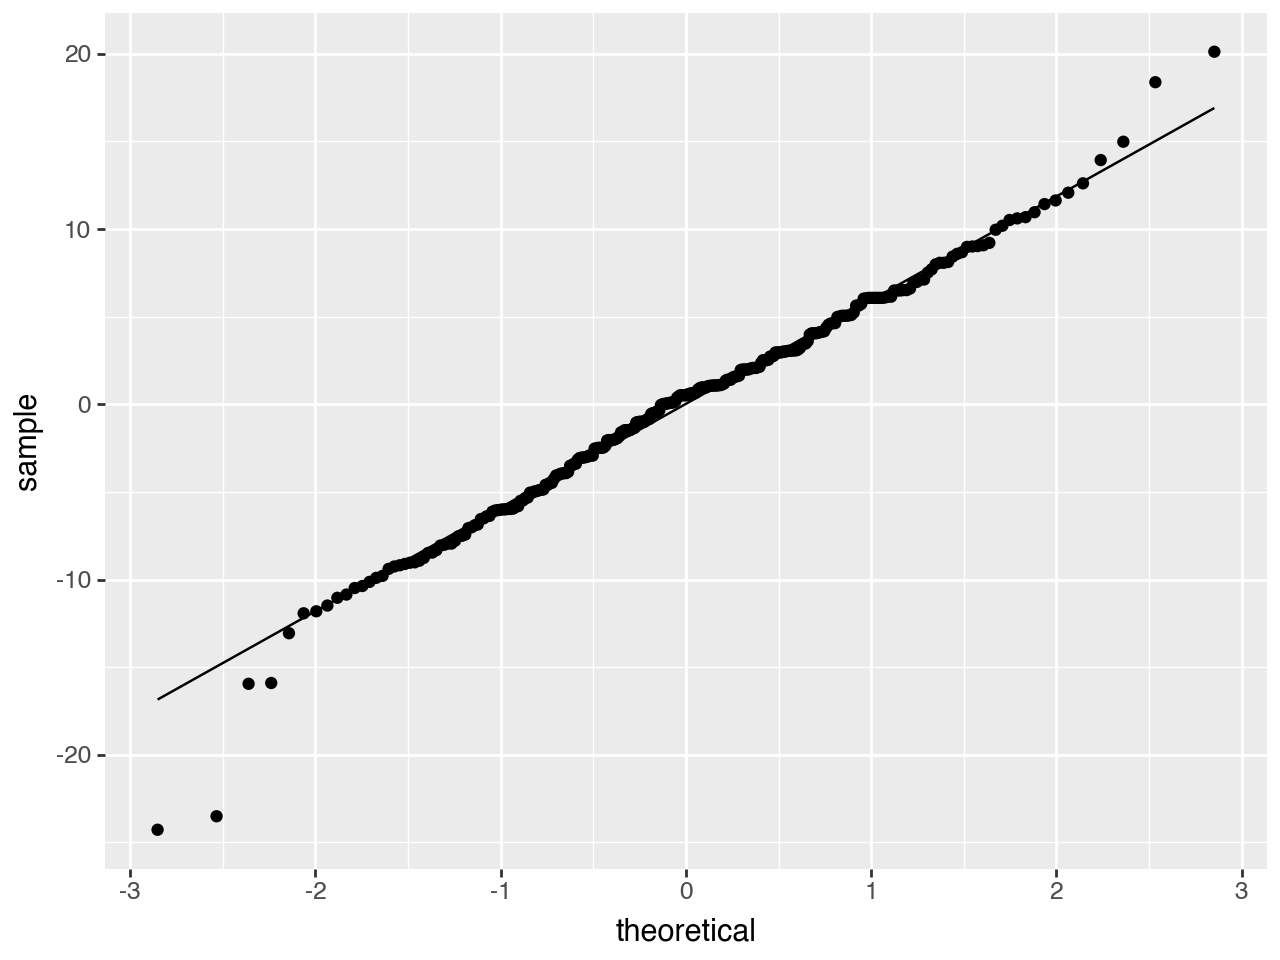

In [116]:
(
    ggplot(heights_male, aes(sample = 'err')) 
    + stat_qq() 
    + stat_qq_line()
)

An implication that the errors follow a Gaussian distribution is that the residuals also follow a Gaussian
distribution. The Q-Q plot supports such distribution.

------

# Section 02 - Linear regression residuals

You’ve fitted a linear model and obtained the associated residual plot. Considering the presented plots,
explain the modifications you would implement to enhance the model’s fit to the data. Justify your
answer considering the assumptions of linear regression.

<img src = '../images/Ekran Resmi 2026-02-10 17.44.01.png' width = 600>

Solution: The residuals non-linearly depend on the fitted values. One should use non-linear models or
non-linear transformation of the features (e.g. polynomial transformation of the features, neural networks,
etc.)

------

# Section 03 - Brain weight

Colleagues tell you that they investigated the relationship between brain weight and body weight across
animals provided in the Animals dataset of the MASS library and did not find a significant association.
This is surprising. You will now investigate.

Start loading the data into a data.table with the following code. The body weights are given in kilogram,
the brain weights in gram.

In [117]:
animals = sm.datasets.get_rdataset("Animals", "MASS").data

dt = pd.DataFrame({
    'name': animals.index,
    'body_weight': animals['body'],
    'brain_weight': animals['brain']
})

dt.head()

,name,body_weight,brain_weight
rownames,,,
Mountain beaver,Mountain beaver,1.35,8.1
Cow,Cow,465.00,423.0
Grey wolf,Grey wolf,36.33,119.5
Goat,Goat,27.66,115.0
Guinea pig,Guinea pig,1.04,5.5


1. Their analysis was based on a linear regression of brain_weight as response variable against
body_weight as explanatory variable and tetsing for the slope to be 0. Reproduce their observation.

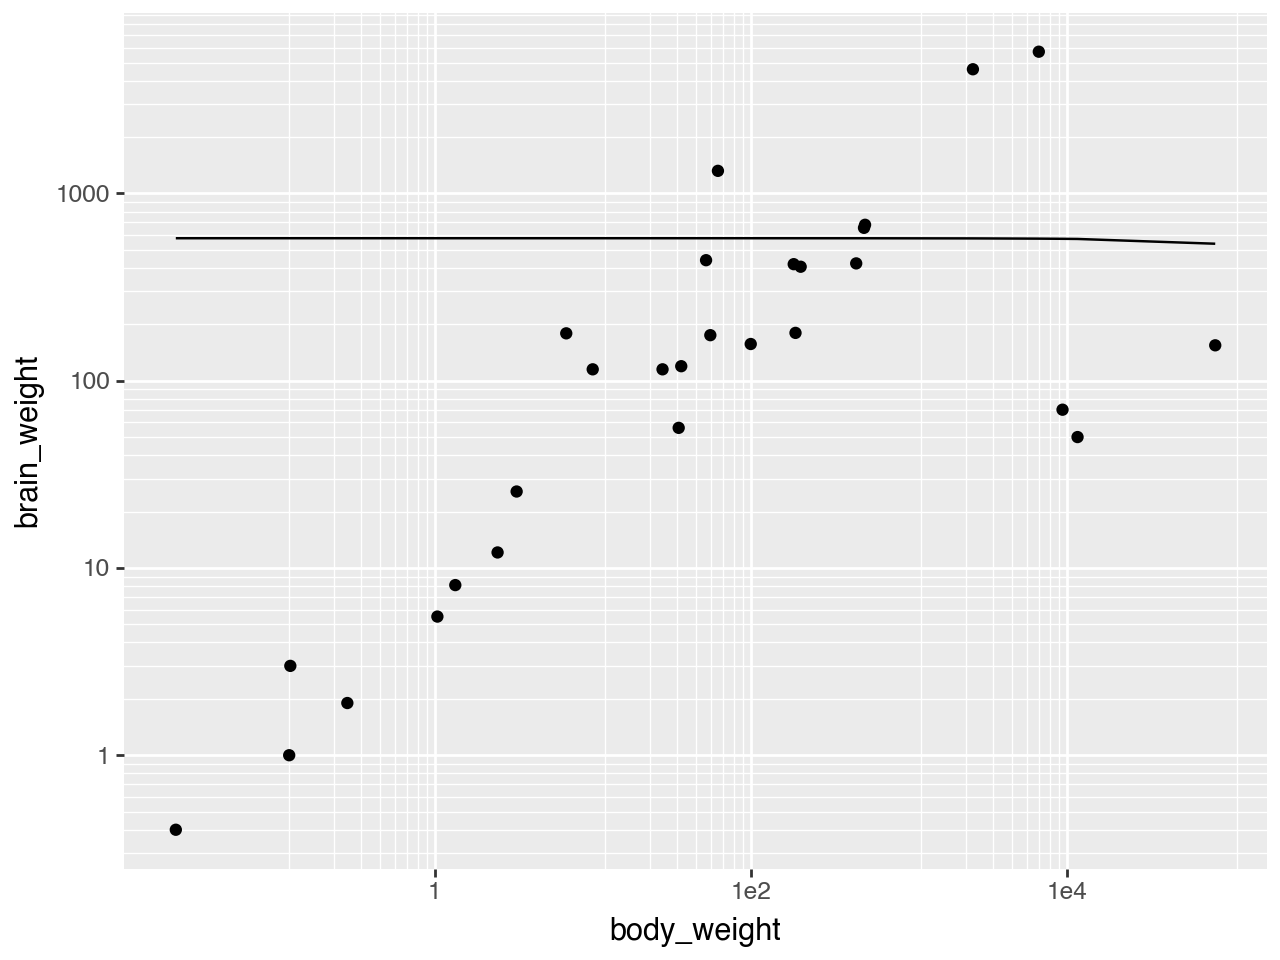

In [118]:
model = smf.ols('brain_weight ~ body_weight', data = dt).fit()

dt['predicted_brain'] = model.predict(dt['body_weight'])

(
    ggplot(dt, aes('body_weight', 'brain_weight')) + 
    geom_point() + 
    geom_line(aes('body_weight', 'predicted_brain')) +
    scale_y_log10() + 
    scale_x_log10()
)

3. From these graphical investigations, you decide to model the relationship between body and brain
weights on a logarithmic scale. Update the data table as follows:

In [119]:
dt['log10_brain_weight'] = np.log10(dt['brain_weight'])

dt['log10_body_weight'] = np.log10(dt['body_weight'])

In [120]:
model2 = smf.ols('log10_brain_weight ~ log10_body_weight', data = dt).fit()

dt['err2'] = model2.resid # residuals

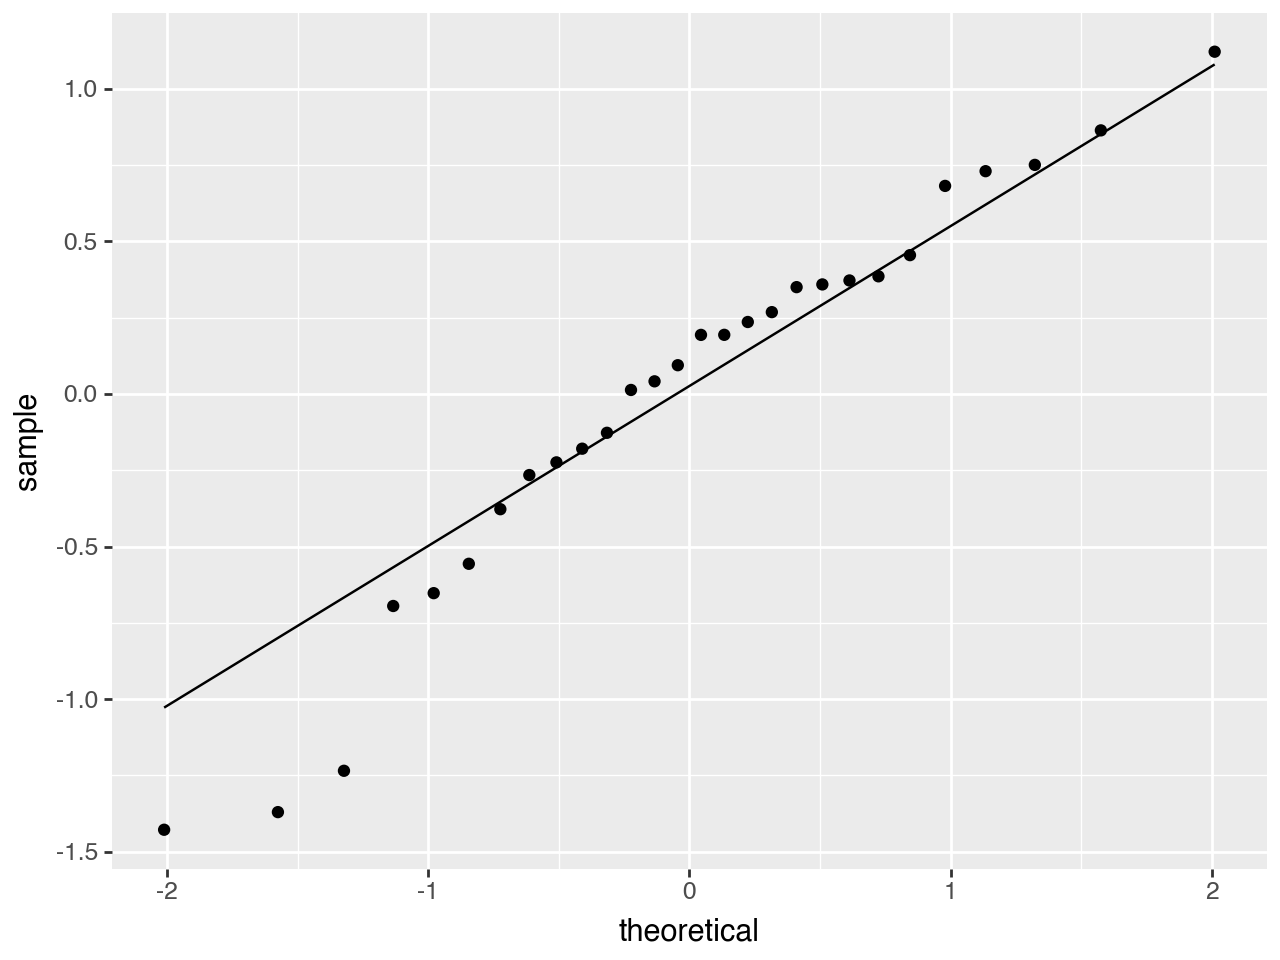

In [121]:
(
    ggplot(dt, aes(sample= 'err2')) +
    geom_qq() +
    geom_qq_line()
)

4. Which data points are leading to a deviation from the statistical assumptions of linear regression?
Comment. Remove them from the dataset and re-iterate. Are assumptions now met or are there new
problematic data points standing out? Which ones? Comment.

In [122]:
print(dt['err2'].sort_values().head())

dt_no_dino = dt[ ~dt['name'].isin(['Dipliodocus', 'Brachiosaurus', 'Triceratops'])].copy()

fit3 = smf.ols('log10_brain_weight ~ log10_body_weight', data = dt_no_dino).fit()
dt_no_dino['err3'] = fit3.resid

rownames
Dipliodocus      -1.428407
Brachiosaurus    -1.370625
Triceratops      -1.235130
Mouse            -0.694944
Golden hamster   -0.652857
Name: err2, dtype: float64


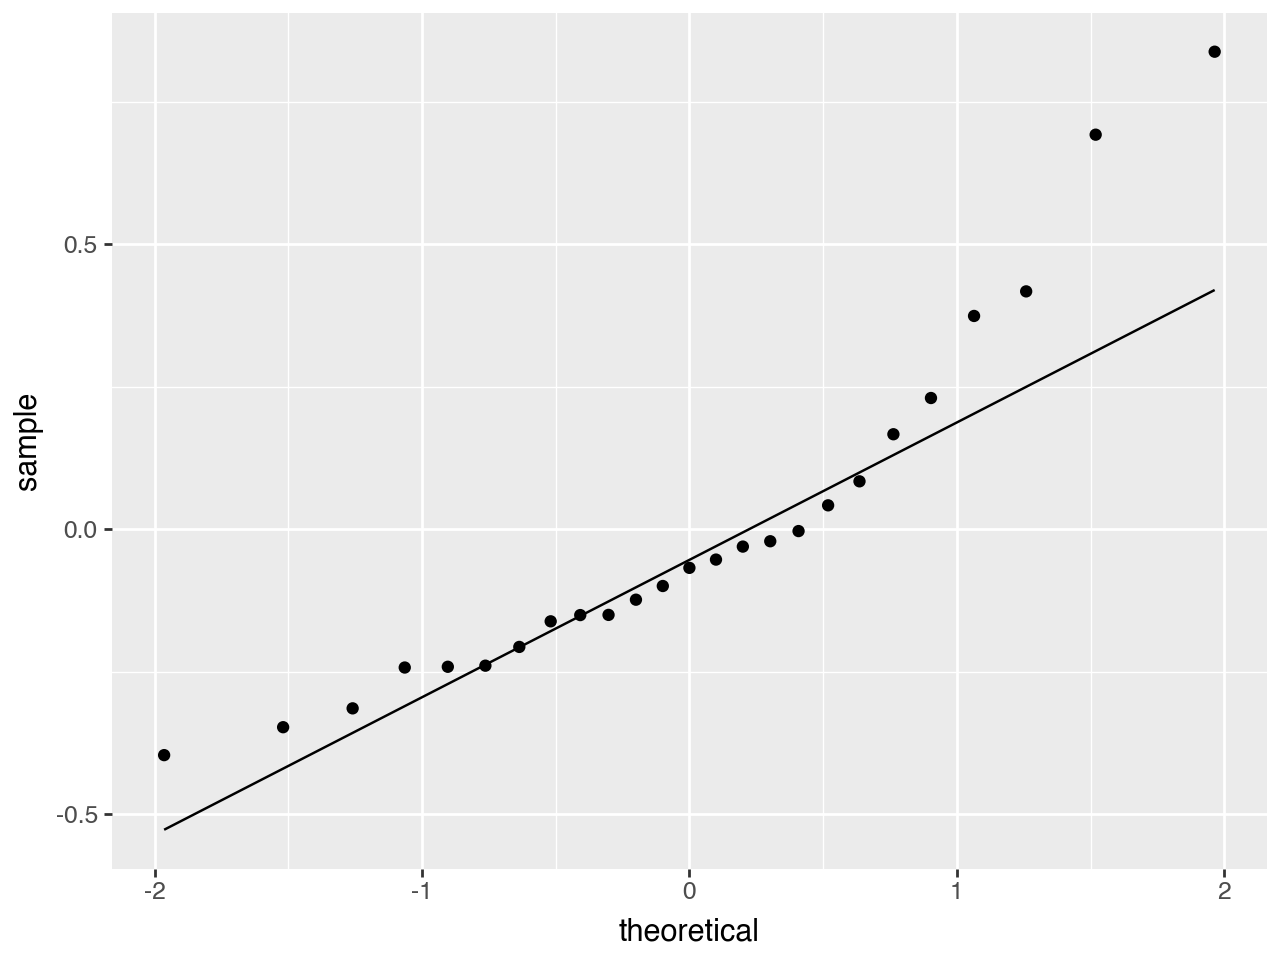

In [124]:
(
    ggplot(dt_no_dino, aes( sample = 'err3')) + 
    geom_qq() + 
    geom_qq_line()
)

In [134]:
print(dt_no_dino['err3'].sort_values(ascending= False).head())

dt_no_human = dt_no_dino[~ dt_no_dino['name'].isin(['Human', 'Rhesus monkey', 'Chimpanzee', 'Potar monkey'])].copy()

rownames
Human            0.838316
Rhesus monkey    0.692677
Chimpanzee       0.417655
Potar monkey     0.374525
Mole             0.230505
Name: err3, dtype: float64


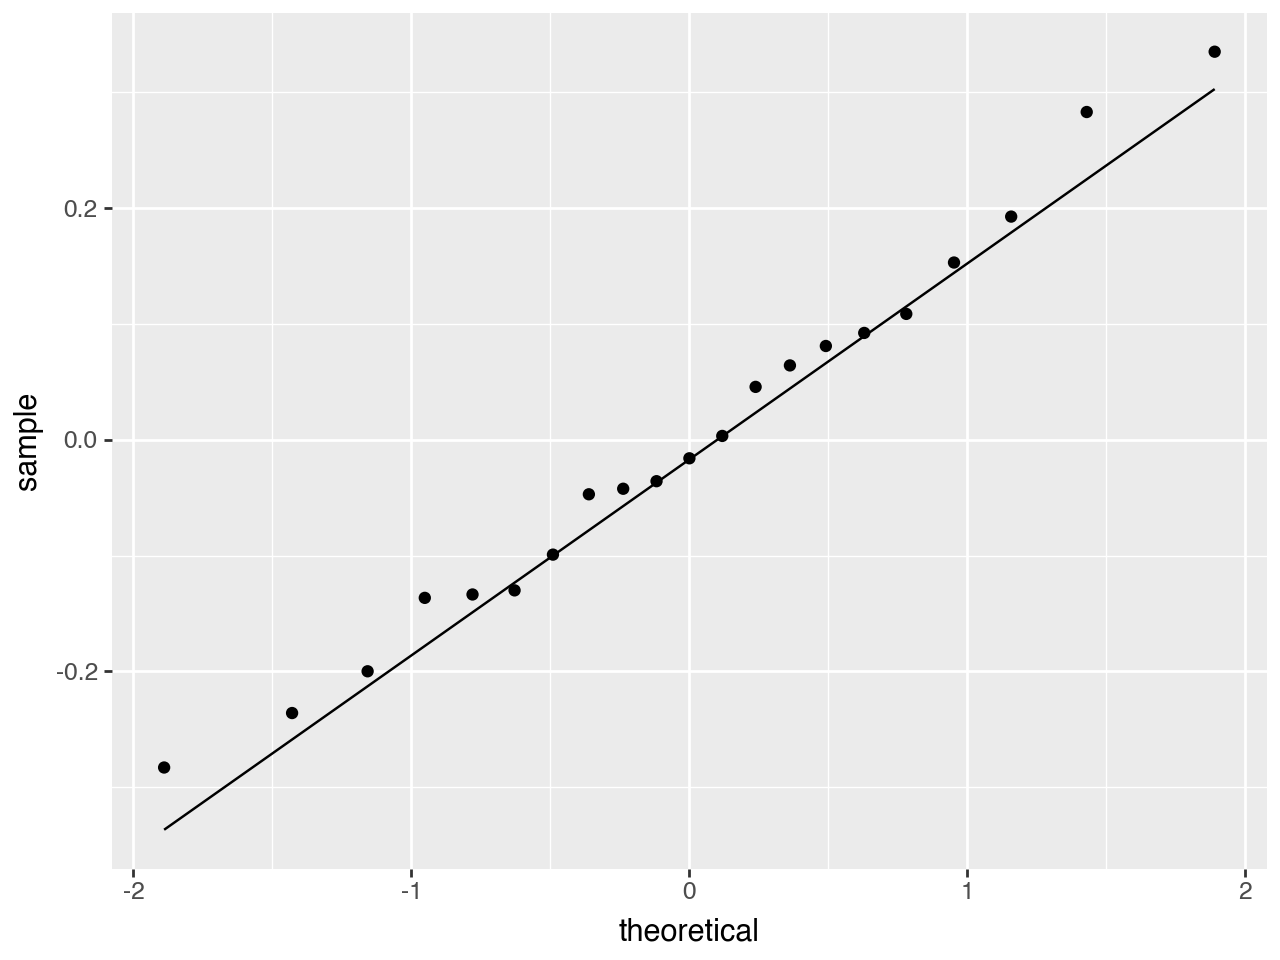

In [137]:
model3 = smf.ols('log10_brain_weight ~ log10_body_weight', data = dt_no_human).fit()

dt_no_human['err4'] = model3.resid

(
    ggplot(dt_no_human, aes(sample = 'err4')) + 
    geom_qq() + 
    geom_qq_line() 
)

5. Suggest an alternative way independent of the Gaussian assumptions to estimate 95% confidence
intervals of the slope on the full dataset. Implement it. What do you find for the full dataset? How does
it compare to the 95% confidence interval returned by linear regression? Hint: for the latter apply the
conf_int() method to the fitted model object.